# CS 763 — Phase 3 Master Notebook

**Project:** Certified Robustness for Temporal Graph Neural Networks via
Shared-Noise Smoothing
**Team:** Rohan Gupta (rkgupta3@wisc.edu), Jeevesh Mahajan
**Phase 3 deadline:** April 30, 2026

This notebook consolidates all four Phase 3 experiments into a single
Colab-runnable file:

| # | Experiment | N (cert) | Output JSON |
|---|---|---|---|
| 1 | Synthetic fraud (canonical) | 1000 | `phase3_temporal_results.json` |
| 2 | Synthetic fraud (confirmation rerun) | 2000 | `phase3_temporal_results_N2000.json` |
| 3 | Cora-temporal (homophilous counterpart) | 1000 | `phase3_temporal_cora_results.json` |
| 4 | Real Elliptic Bitcoin graph | 1500 | `phase3_temporal_elliptic_results.json` |

For each experiment we compare three certificate variants:

- **Aggregate** — standard NP certificate on the full static graph (baseline).
- **Naive temporal (union-bound)** — per-window NP cert with Bonferroni
  α/T confidence.
- **Shared-noise temporal** — one global edge-flip mask, T per-window
  forwards, softmax-sum aggregation, no Bonferroni.

**How to run.** Open in Colab → set runtime to GPU → set the
`EXPERIMENTS_TO_RUN` flags in Section B → Run All. Each experiment trains
its own GCN and saves its own JSON. The final cell prints a cross-experiment
summary table.


## A. Setup — install, imports, and primitives

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# A.1 Install. (Colab needs torch_geometric; pandas/scikit/scipy preinstalled.)
!pip install -q torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00


In [3]:
# A.2 Imports + global seed.
import os, random, math, time, json, copy
from dataclasses import dataclass
from typing import List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import beta as scipy_beta
from sklearn.metrics import f1_score

from torch_geometric.nn import GCNConv
from torch_geometric.utils import homophily, to_undirected
from torch_geometric.datasets import Planetoid, EllipticBitcoinDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")
print(f"torch:  {torch.__version__}")

SEED = 42
def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

DEVICE: cuda
torch:  2.10.0+cu128


In [4]:
# A.3 Model + uniform edge-flip noise + Clopper-Pearson lower bound.
class GCN(nn.Module):
    def __init__(self, in_dim, hidden, out_dim, dropout=0.5):
        super().__init__()
        self.c1 = GCNConv(in_dim, hidden)
        self.c2 = GCNConv(hidden, out_dim)
        self.dropout = dropout
    def forward(self, x, edge_index):
        h = self.c1(x, edge_index); h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.c2(h, edge_index)


def flip_edges_uniform(edge_index, num_nodes, flip_prob, p_add, seed=None):
    device = edge_index.device
    g = torch.Generator(device=device)
    if seed is not None: g.manual_seed(seed)
    keep = torch.rand(edge_index.shape[1], device=device, generator=g) > flip_prob
    kept = edge_index[:, keep]
    n_add = int(p_add * edge_index.shape[1])
    if n_add > 0:
        new_src = torch.randint(0, num_nodes, (n_add,), device=device, generator=g)
        new_dst = torch.randint(0, num_nodes, (n_add,), device=device, generator=g)
        return torch.cat([kept, torch.stack([new_src, new_dst], dim=0)], dim=1)
    return kept


def clopper_pearson_lower(k, n, alpha):
    if k == 0: return 0.0
    return float(scipy_beta.ppf(alpha, k, n - k + 1))

In [5]:
# A.4 Neyman-Pearson certificate (Bojchevski & Gunnemann 2020, Cor. 1).
def _np_cdfs_on_grid(p_es, grid_step=1e-3):
    p_es = np.clip(p_es, 1e-6, 1.0 - 1e-6)
    w_es = np.log((1.0 - p_es) / p_es)
    w_int = np.maximum(1, np.round(w_es / grid_step).astype(np.int64))
    total = int(w_int.sum()); n_vals = 2 * total + 1
    pmf_P = np.zeros(n_vals); pmf_Q = np.zeros(n_vals)
    pmf_P[total] = 1.0; pmf_Q[total] = 1.0
    for p_e, w in zip(p_es, w_int):
        w = int(w)
        new_P = np.zeros(n_vals); new_Q = np.zeros(n_vals)
        new_P[w:]         += p_e * pmf_P[:n_vals - w]
        new_P[:n_vals-w]  += (1.0 - p_e) * pmf_P[w:]
        new_Q[w:]         += (1.0 - p_e) * pmf_Q[:n_vals - w]
        new_Q[:n_vals-w]  += p_e * pmf_Q[w:]
        pmf_P, pmf_Q = new_P, new_Q
    return pmf_P, pmf_Q


def _np_Q_lower(p_A_lower, p_es, grid_step=1e-3):
    if len(p_es) == 0: return p_A_lower
    pmf_P, pmf_Q = _np_cdfs_on_grid(np.asarray(p_es), grid_step)
    cdf_P = np.cumsum(pmf_P); cdf_Q = np.cumsum(pmf_Q)
    k = int(np.searchsorted(cdf_P, p_A_lower, side="left"))
    if k >= len(cdf_P): k = len(cdf_P) - 1
    cdf_P_prev = cdf_P[k - 1] if k > 0 else 0.0
    cdf_Q_prev = cdf_Q[k - 1] if k > 0 else 0.0
    bin_P = cdf_P[k] - cdf_P_prev; bin_Q = cdf_Q[k] - cdf_Q_prev
    if bin_P > 0:
        frac = (p_A_lower - cdf_P_prev) / bin_P
        return float(cdf_Q_prev + frac * bin_Q)
    return float(cdf_Q_prev)


def cert_radius_np(p_A_lower, flip_probs_1d, max_radius=20):
    if p_A_lower <= 0.5: return 0
    p_sorted = np.sort(np.asarray(flip_probs_1d))
    M = min(max_radius, len(p_sorted))
    R = 0
    for r_cand in range(1, M + 1):
        if _np_Q_lower(p_A_lower, p_sorted[:r_cand]) > 0.5:
            R = r_cand
        else:
            break
    return R

In [6]:
# A.5 Single-graph cert sampling helpers (used by aggregate + naive).
@torch.no_grad()
def sample_counts(model, x, edge_index, num_nodes, target, flip_prob, p_add,
                  n_samples, batch_size, num_classes, base_seed=0):
    counts = np.zeros(num_classes, dtype=np.int64)
    for i in range(n_samples):
        noisy = flip_edges_uniform(edge_index, num_nodes, flip_prob, p_add,
                                   seed=base_seed + i)
        logits = model(x, noisy)
        counts[int(logits[target].argmax().item())] += 1
    return counts


def smooth_and_cert(model, x, edge_index, num_nodes, target, flip_prob, cfg,
                    num_classes, alpha=None, base_seed=0):
    if alpha is None: alpha = cfg["alpha"]
    c0 = sample_counts(model, x, edge_index, num_nodes, target, flip_prob, cfg["p_add"],
                       cfg["N0"], cfg["batch_size"], num_classes, base_seed)
    c_hat = int(np.argmax(c0))
    cn = sample_counts(model, x, edge_index, num_nodes, target, flip_prob, cfg["p_add"],
                       cfg["N"], cfg["batch_size"], num_classes, base_seed + 10_000)
    p_A = clopper_pearson_lower(int(cn[c_hat]), cfg["N"], alpha)
    flip_vec = np.full(edge_index.shape[1], flip_prob)
    R = 0 if p_A <= 0.5 else cert_radius_np(p_A, flip_vec)
    return {"node": target, "c_hat": c_hat, "p_A": p_A,
            "abstain": p_A <= 0.5, "R_star": R}


def certify_on_subgraph(model, x, edge_index_sub, num_nodes, nodes, flip_prob, cfg,
                        num_classes, y_dev, tag, alpha=None):
    results = []; t0 = time.time()
    for i, v in enumerate(nodes):
        r = smooth_and_cert(model, x, edge_index_sub, num_nodes, v, flip_prob, cfg,
                            num_classes, alpha=alpha, base_seed=SEED + 1000 * i)
        y_true = int(y_dev[v].item())
        r["y_true"] = y_true
        r["correct"] = int(r["c_hat"] == y_true) if not r["abstain"] else 0
        r["tag"] = tag
        results.append(r)
        if (i + 1) % 10 == 0:
            mR = np.mean([x_["R_star"] for x_ in results])
            mP = np.mean([x_["p_A"] for x_ in results])
            print(f"  [{tag}] {i+1}/{len(nodes)}  R*={mR:.2f}  p_A={mP:.3f}")
    print(f"  [{tag}] done in {time.time()-t0:.1f}s  (|E|={edge_index_sub.shape[1]})")
    return results


def cert_acc_curve(results, radii):
    return np.array([
        np.mean([1.0 if (r["correct"] and r["R_star"] >= R) else 0.0 for r in results])
        for R in radii
    ])


def balanced_sample(y, mask, per_class, num_classes, seed=SEED):
    rng = np.random.default_rng(seed)
    out = []
    for c in range(num_classes):
        idx = ((y == c) & mask).nonzero(as_tuple=True)[0].cpu().numpy()
        if len(idx) == 0: continue
        out.extend(rng.choice(idx, size=min(per_class, len(idx)), replace=False).tolist())
    return sorted(out)

In [7]:
# A.6 Shared-noise temporal sampling + certification.
def flip_edges_shared(ei, edge_mask_per_window, num_nodes, flip_prob, p_add, seed):
    """Shared noise: ONE keep_mask over full E, restricted per window + p_add per window."""
    device = ei.device
    g = torch.Generator(device=device); g.manual_seed(seed)
    keep_mask = torch.rand(ei.shape[1], device=device, generator=g) > flip_prob
    per_window_ei = []
    for em in edge_mask_per_window:
        em_kept = em & keep_mask
        ei_w = ei[:, em_kept]
        n_add = int(p_add * int(em.sum()))
        if n_add > 0:
            new_src = torch.randint(0, num_nodes, (n_add,), device=device, generator=g)
            new_dst = torch.randint(0, num_nodes, (n_add,), device=device, generator=g)
            ei_w = torch.cat([ei_w, torch.stack([new_src, new_dst], dim=0)], dim=1)
        per_window_ei.append(ei_w)
    return per_window_ei


@torch.no_grad()
def sample_counts_shared(model, x, ei, edge_mask_per_window, test_nodes_t,
                         flip_prob, p_add, n_samples, num_classes, base_seed=0):
    """One shared xi per draw -> T per-window forwards -> softmax-sum -> argmax per node."""
    counts = np.zeros((len(test_nodes_t), num_classes), dtype=np.int64)
    T = len(edge_mask_per_window)
    for i in range(n_samples):
        per_win_ei = flip_edges_shared(ei, edge_mask_per_window, x.shape[0],
                                       flip_prob, p_add, seed=base_seed + i)
        logits_sum = torch.zeros(len(test_nodes_t), num_classes, device=DEVICE)
        for t in range(T):
            lg = model(x, per_win_ei[t])[test_nodes_t]
            logits_sum += F.softmax(lg, dim=-1)
        pred = logits_sum.argmax(-1).cpu().numpy()
        for j, c in enumerate(pred):
            counts[j, c] += 1
        if (i + 1) % 200 == 0:
            print(f"    shared-noise sample {i+1}/{n_samples}")
    return counts


def certify_shared_noise(model, x, ei, edge_mask_per_window, test_nodes,
                         flip_prob, cfg, num_classes, y_dev, tag="shared"):
    """NP certificate on full edge set under shared-noise aggregated classifier.
    alpha NOT divided by T — single joint event under shared noise."""
    t0 = time.time()
    test_nodes_t = torch.tensor(test_nodes, device=DEVICE)
    print(f"  [{tag}] stage 1 (selection, N0={cfg['N0']}) ...")
    c0 = sample_counts_shared(model, x, ei, edge_mask_per_window, test_nodes_t,
                              flip_prob, cfg["p_add"], cfg["N0"], num_classes,
                              base_seed=SEED)
    c_hat = c0.argmax(axis=1)
    print(f"  [{tag}] stage 2 (estimation, N={cfg['N']}) ...")
    cn = sample_counts_shared(model, x, ei, edge_mask_per_window, test_nodes_t,
                              flip_prob, cfg["p_add"], cfg["N"], num_classes,
                              base_seed=SEED + 10_000)
    flip_vec_full = np.full(ei.shape[1], flip_prob)
    results = []
    for j, v in enumerate(test_nodes):
        k = int(cn[j, c_hat[j]])
        p_A = clopper_pearson_lower(k, cfg["N"], cfg["alpha"])
        R = 0 if p_A <= 0.5 else cert_radius_np(p_A, flip_vec_full)
        y_true = int(y_dev[v].item())
        abstain = p_A <= 0.5
        correct = int(c_hat[j] == y_true) if not abstain else 0
        results.append({
            "node": int(v), "c_hat": int(c_hat[j]), "p_A": float(p_A),
            "abstain": bool(abstain), "R_star": int(R),
            "y_true": y_true, "correct": correct, "tag": tag,
        })
    print(f"  [{tag}] done in {time.time()-t0:.1f}s  (|V|={len(test_nodes)}, T={len(edge_mask_per_window)})")
    return results

In [8]:
# A.7 Training loop — uniform-noise GCN with class weights and early stopping.
def train_uniform_gcn(x, ei, y, train_mask, val_mask, num_classes, cfg):
    set_seed(cfg["seed"])
    model = GCN(x.shape[1], cfg["hidden_dim"], num_classes,
                dropout=cfg["dropout"]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"],
                           weight_decay=cfg["weight_decay"])
    if cfg.get("class_weights") is not None:
        crit = nn.CrossEntropyLoss(
            weight=torch.tensor(cfg["class_weights"], device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()
    best, best_state, patience = -1.0, None, cfg["patience"]
    t0 = time.time()
    for ep in range(1, cfg["epochs"] + 1):
        model.train()
        noisy = flip_edges_uniform(ei, x.shape[0], cfg["p_noise_train"],
                                   p_add=0.01, seed=cfg["seed"] + ep)
        logits = model(x, noisy)
        loss = crit(logits[train_mask], y[train_mask])
        opt.zero_grad(); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(x, ei).argmax(-1)
            if num_classes == 2:
                vs = f1_score(y[val_mask].cpu().numpy(),
                              vp[val_mask].cpu().numpy(),
                              pos_label=1, zero_division=0)
            else:
                vs = (vp[val_mask] == y[val_mask]).float().mean().item()
        if vs > best:
            best = vs
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience = cfg["patience"]
        else:
            patience -= 1
        if ep % cfg["log_every"] == 0 or ep == 1:
            print(f"  ep {ep:3d}  loss {loss.item():.4f}  val {vs:.4f}  (best {best:.4f})")
        if patience <= 0:
            print(f"  early stop @ ep {ep}"); break
    model.load_state_dict(best_state); model.eval()
    print(f"  trained in {time.time()-t0:.1f}s  (best val={best:.4f})")
    return model

In [9]:
# A.8 Single-experiment pipeline: aggregate / naive / shared cert + JSON save.
def run_temporal_experiment(
    *, name, model, x, ei, y, num_nodes, num_classes,
    edge_mask_per_window, node_mask_per_window, WINDOWS, T_WIN,
    pooled_eval_nodes, window_eval_nodes,
    CFG_CERT, edge_hom_full, output_json_path, extra_meta=None,
):
    """Runs all three certificate variants and writes a JSON."""
    radii = CFG_CERT["radii"]
    print(f"\n{'#' * 72}\n# RUN: {name}\n{'#' * 72}\n")

    # ---- Aggregate cert
    print("=== AGGREGATE CERT (full static graph, alpha=0.01) ===")
    agg_results = certify_on_subgraph(
        model, x, ei, num_nodes, pooled_eval_nodes, CFG_CERT["p_smooth"],
        CFG_CERT, num_classes=num_classes, y_dev=y, tag="aggregate",
    )
    ca_agg = cert_acc_curve(agg_results, radii)
    print(f"\nAggregate: mean_p_A = {np.mean([r['p_A'] for r in agg_results]):.3f}  "
          f"mean_R* = {np.mean([r['R_star'] for r in agg_results]):.2f}")
    print("CertAcc:  " + "  ".join(f"R={R} {ca_agg[R]:.3f}" for R in [0,1,2,3,5]))

    # ---- Naive temporal cert (Bonferroni over T windows)
    alpha_w = CFG_CERT["alpha"] / T_WIN
    print(f"\n=== NAIVE TEMPORAL CERT (Bonferroni alpha = {alpha_w:.4f}) ===")
    window_results = []
    for wi, (nodes, em) in enumerate(zip(window_eval_nodes, edge_mask_per_window)):
        ei_w = ei[:, em]
        print(f"\n  -- window {wi+1} ({WINDOWS[wi]})  |E_w|={ei_w.shape[1]}, test={len(nodes)}")
        res = certify_on_subgraph(
            model, x, ei_w, num_nodes, nodes, CFG_CERT["p_smooth"], CFG_CERT,
            num_classes=num_classes, y_dev=y, tag=f"w{wi+1}", alpha=alpha_w,
        )
        window_results.append(res)
    pooled_window_results = []
    for res in window_results: pooled_window_results.extend(res)
    ca_win = cert_acc_curve(pooled_window_results, radii)

    # ---- Shared-noise temporal cert
    print("\n=== SHARED-NOISE TEMPORAL CERT (alpha=0.01, no Bonferroni) ===")
    shared_results = certify_shared_noise(
        model, x, ei, edge_mask_per_window, pooled_eval_nodes,
        CFG_CERT["p_smooth"], CFG_CERT,
        num_classes=num_classes, y_dev=y, tag="shared",
    )
    ca_shared = cert_acc_curve(shared_results, radii)
    mean_pA_shared = float(np.mean([r["p_A"] for r in shared_results]))
    mean_R_shared  = float(np.mean([r["R_star"] for r in shared_results]))
    print(f"\nShared-noise: mean_p_A = {mean_pA_shared:.3f}  mean_R* = {mean_R_shared:.2f}")

    # ---- Matched-node head-to-head
    node_set = set(pooled_eval_nodes)
    agg_same    = [r for r in agg_results    if r["node"] in node_set]
    shared_same = [r for r in shared_results if r["node"] in node_set]
    win_lookup = {r["node"]: r for r in pooled_window_results}
    win_same = [win_lookup[v] for v in pooled_eval_nodes if v in win_lookup]
    ca_agg_m    = cert_acc_curve(agg_same,    radii)
    ca_win_m    = cert_acc_curve(win_same,    radii)
    ca_shared_m = cert_acc_curve(shared_same, radii)
    n_match = min(len(agg_same), len(win_same), len(shared_same))

    print(f"\nHEAD-TO-HEAD (matched, |V|={n_match})")
    print(f"{'R':<3s} {'agg':<8s} {'naive':<8s} {'shared':<8s} {'d(n-a)':<9s} {'d(s-a)':<9s}")
    for R in radii:
        dn = ca_win_m[R]    - ca_agg_m[R]
        ds = ca_shared_m[R] - ca_agg_m[R]
        m = " <=" if R == 2 else ""
        print(f"{R:<3d} {ca_agg_m[R]:<8.3f} {ca_win_m[R]:<8.3f} {ca_shared_m[R]:<8.3f} "
              f"{dn:+.3f}    {ds:+.3f}{m}")

    delta_R2_naive  = float(ca_win_m[2]    - ca_agg_m[2])
    delta_R3_naive  = float(ca_win_m[3]    - ca_agg_m[3])
    delta_R2_shared = float(ca_shared_m[2] - ca_agg_m[2])
    delta_R3_shared = float(ca_shared_m[3] - ca_agg_m[3])
    delta_R2_shared_vs_naive = float(ca_shared_m[2] - ca_win_m[2])
    shared_recovers    = delta_R2_shared >= -0.02
    shared_beats_naive = delta_R2_shared_vs_naive >= 0.05

    # ---- Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(radii, ca_agg_m,    "s--", label="aggregate",    lw=2)
    axes[0].plot(radii, ca_win_m,    "o-",  label="naive",        lw=2)
    axes[0].plot(radii, ca_shared_m, "^-",  label="shared-noise", lw=2)
    axes[0].axvline(2, color="red", ls=":", alpha=0.6, label="R=2 (Phase-1 median)")
    axes[0].set_xlabel("R"); axes[0].set_ylabel("CertAcc")
    axes[0].set_title(f"{name} (n={n_match})")
    axes[0].set_ylim(-0.02, 1.02); axes[0].legend(); axes[0].grid(alpha=0.3)
    labels = ["R=1","R=2","R=3","R=5"]; xp = np.arange(4); w = 0.27
    axes[1].bar(xp - w, [ca_agg_m[1],ca_agg_m[2],ca_agg_m[3],ca_agg_m[5]], w, label="agg")
    axes[1].bar(xp,     [ca_win_m[1],ca_win_m[2],ca_win_m[3],ca_win_m[5]], w, label="naive")
    axes[1].bar(xp + w, [ca_shared_m[1],ca_shared_m[2],ca_shared_m[3],ca_shared_m[5]], w, label="shared")
    axes[1].set_xticks(xp); axes[1].set_xticklabels(labels); axes[1].set_ylim(0,1)
    axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

    # ---- Per-window drift plot
    per_window_CA0 = []; per_window_CA2 = []; per_window_CA3 = []; window_labels = []
    for wi, res in enumerate(window_results):
        ca = cert_acc_curve(res, radii)
        per_window_CA0.append(float(ca[0]))
        per_window_CA2.append(float(ca[2]))
        per_window_CA3.append(float(ca[3]))
        window_labels.append(f"w{wi+1}\n{WINDOWS[wi]}")
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    xp = np.arange(T_WIN)
    ax.plot(xp, per_window_CA0, "s--", label="R=0")
    ax.plot(xp, per_window_CA2, "o-",  label="R=2 (primary)")
    ax.plot(xp, per_window_CA3, "^-",  label="R=3 (stretch)")
    ax.set_xticks(xp); ax.set_xticklabels(window_labels)
    ax.set_ylabel("CertAcc"); ax.set_title(f"{name} — per-window drift")
    ax.set_ylim(0, 1.02); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- Save JSON (matches existing artifact format)
    out = {
        "config": CFG_CERT,
        "run_tag": name,
        "windows": [list(w) for w in WINDOWS],
        "per_window_edge_counts": [int(em.sum()) for em in edge_mask_per_window],
        "per_window_test_counts": [int(nm.sum()) for nm in node_mask_per_window],
        "bonferroni_alpha": alpha_w,
        "edge_homophily": float(edge_hom_full),
        "aggregate": {
            "cert_acc_curve": ca_agg_m.tolist(),
            "mean_p_A": float(np.mean([r["p_A"] for r in agg_same])),
            "mean_R*": float(np.mean([r["R_star"] for r in agg_same])),
            "per_node": agg_same,
        },
        "temporal_union_bound": {
            "cert_acc_curve": ca_win_m.tolist(),
            "mean_p_A": float(np.mean([r["p_A"] for r in win_same])),
            "mean_R*": float(np.mean([r["R_star"] for r in win_same])),
            "per_node": win_same,
            "per_window": [
                {
                    "window": list(WINDOWS[wi]),
                    "edge_count": int(em.sum()),
                    "test_count": len(res),
                    "cert_acc_curve": cert_acc_curve(res, radii).tolist(),
                    "mean_p_A": float(np.mean([r["p_A"] for r in res])),
                    "mean_R*": float(np.mean([r["R_star"] for r in res])),
                }
                for wi, (res, em) in enumerate(zip(window_results, edge_mask_per_window))
            ],
        },
        "shared_noise": {
            "cert_acc_curve": ca_shared_m.tolist(),
            "mean_p_A": mean_pA_shared,
            "mean_R*": mean_R_shared,
            "per_node": shared_same,
            "alpha_used": CFG_CERT["alpha"],
            "note": ("Full-graph NP cert; alpha NOT Bonferroni-corrected; "
                     "softmax-sum over T window passes with shared noise."),
        },
        "headline": {
            "delta_R2_naive_vs_agg":    delta_R2_naive,
            "delta_R3_naive_vs_agg":    delta_R3_naive,
            "delta_R2_shared_vs_agg":   delta_R2_shared,
            "delta_R3_shared_vs_agg":   delta_R3_shared,
            "delta_R2_shared_vs_naive": delta_R2_shared_vs_naive,
            "shared_recovers_to_agg_parity": bool(shared_recovers),
            "shared_beats_naive":            bool(shared_beats_naive),
        },
        "per_window_over_time": {
            "labels": window_labels,
            "CertAcc_R0": per_window_CA0,
            "CertAcc_R2": per_window_CA2,
            "CertAcc_R3": per_window_CA3,
        },
    }
    if extra_meta: out.update(extra_meta)

    with open(output_json_path, "w") as f:
        json.dump(out, f, indent=2, default=str)
    print(f"\nWrote {output_json_path}")
    print(f"VERDICT [{name}]: shared@R=2 = {ca_shared_m[2]:.3f}, "
          f"agg@R=2 = {ca_agg_m[2]:.3f}, "
          f"d(shared-agg) = {delta_R2_shared:+.3f}")
    return out

## B. Experiment selector

Toggle the flags below to choose which experiments to run. Defaults to all four.

> **Tip:** On a free Colab GPU each fraud / Cora experiment takes ~5–10 minutes.
> The Elliptic experiment takes ~7 minutes (full graph forward passes).
> Total wall-clock for all four ≈ 25–35 minutes.


In [10]:
EXPERIMENTS_TO_RUN = {
    "fraud_N1000":   True,  # canonical synthetic fraud, N=1000
    "fraud_N2000":   True,  # synthetic fraud confirmation rerun, N=2000
    "cora_temporal": True,  # Cora with hashed timesteps (homophilous counterpart)
    "elliptic_real": True,  # real Elliptic Bitcoin graph
}

OUTPUT_DIR = "/content/drive/MyDrive"  # JSONs will be written here. On Colab, "." is /content/
print("Will run:", [k for k, v in EXPERIMENTS_TO_RUN.items() if v])

Will run: ['fraud_N1000', 'fraud_N2000', 'cora_temporal', 'elliptic_real']


## D. Experiment 1 — Synthetic fraud (N=1000, canonical)

Heterophilous synthetic fraud graph (~12k nodes, ~130k directed edges, 25 timesteps,
edge homophily ≈ 0.42). This is the canonical Phase 3 run. Requires
`synthetic_fraud_graph.py` to be uploaded to the working directory (Colab: drag-drop
into the Files panel).

**Windows:** w1=[18,19], w2=[20,21], w3=[22,24]. Test = t≥18, val = t∈[15,17],
train = t≤14.

Fraud-synthetic: N=12000, |E|=129798, edge_homophily=0.439

>>> Training uniform-noise GCN on synthetic fraud
  ep   1  loss 0.7520  val 0.3364  (best 0.3364)
  ep  50  loss 0.2617  val 0.7054  (best 0.7671)
  ep 100  loss 0.2344  val 0.7304  (best 0.7961)
  early stop @ ep 142
  trained in 2.4s  (best val=0.8233)
Pooled eval: 60 nodes

########################################################################
# RUN: synth_fraud_N1000
########################################################################

=== AGGREGATE CERT (full static graph, alpha=0.01) ===
  [aggregate] 10/60  R*=0.90  p_A=0.886
  [aggregate] 20/60  R*=1.35  p_A=0.940
  [aggregate] 30/60  R*=1.23  p_A=0.930
  [aggregate] 40/60  R*=1.20  p_A=0.935
  [aggregate] 50/60  R*=1.16  p_A=0.937
  [aggregate] 60/60  R*=1.13  p_A=0.937
  [aggregate] done in 160.8s  (|E|=129798)

Aggregate: mean_p_A = 0.937  mean_R* = 1.13
CertAcc:  R=0 0.933  R=1 0.750  R=2 0.383  R=3 0.000  R=5 0.000

=== NAIVE TEMPORAL CERT (Bonferroni alpha

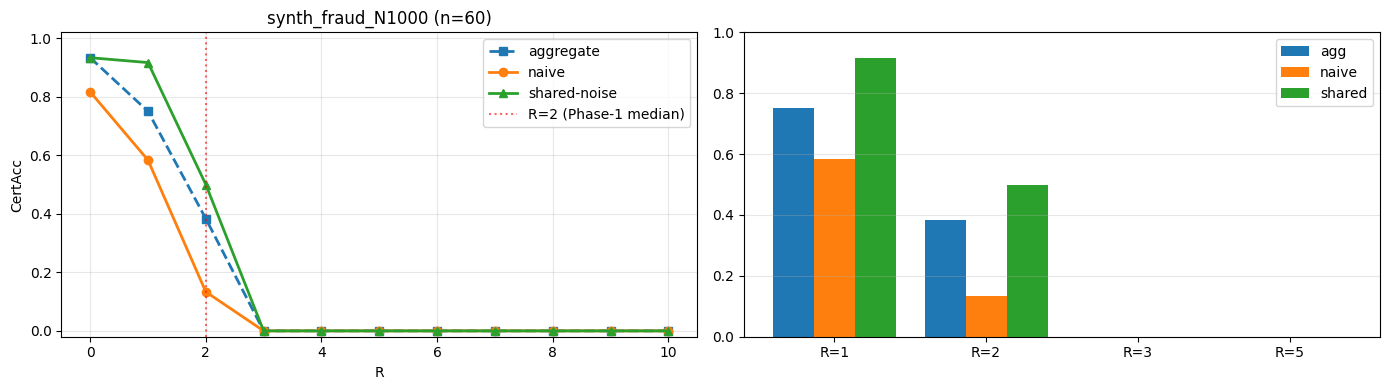

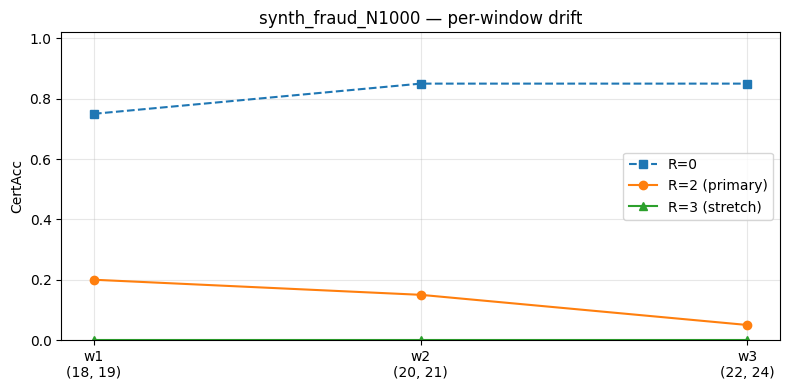


Wrote /content/drive/MyDrive/phase3_temporal_results.json
VERDICT [synth_fraud_N1000]: shared@R=2 = 0.500, agg@R=2 = 0.383, d(shared-agg) = +0.117


In [12]:
if EXPERIMENTS_TO_RUN["fraud_N1000"]:
    try:
        from synthetic_fraud_graph import generate_fraud_graph
    except ImportError as e:
        raise RuntimeError(
            "Upload synthetic_fraud_graph.py to the working directory."
        ) from e

    set_seed(SEED)
    fraud_data, TIMESTEP_FRAUD = generate_fraud_graph()
    x_f  = fraud_data.x.to(DEVICE)
    y_f  = fraud_data.y.to(DEVICE)
    ei_f = fraud_data.edge_index.to(DEVICE)
    TIMESTEP_FRAUD = TIMESTEP_FRAUD.to(DEVICE)
    Nf = x_f.shape[0]
    NUM_CLASSES_F = 2

    labeled_f = y_f >= 0
    train_mask_f = (labeled_f & (TIMESTEP_FRAUD <= 14)).to(DEVICE)
    val_mask_f   = (labeled_f & (TIMESTEP_FRAUD >= 15) & (TIMESTEP_FRAUD <= 17)).to(DEVICE)
    test_mask_f  = (labeled_f & (TIMESTEP_FRAUD >= 18)).to(DEVICE)

    edge_t_f = torch.maximum(TIMESTEP_FRAUD[ei_f[0]], TIMESTEP_FRAUD[ei_f[1]])
    edge_hom_f = float(homophily(ei_f, y_f.clamp(min=0), method="edge"))
    print(f"Fraud-synthetic: N={Nf}, |E|={ei_f.shape[1]}, edge_homophily={edge_hom_f:.3f}")

    WINDOWS_F = [(18, 19), (20, 21), (22, 24)]
    T_WIN_F = len(WINDOWS_F)
    edge_mask_pw_f = []; node_mask_pw_f = []
    for (a, b) in WINDOWS_F:
        edge_mask_pw_f.append((edge_t_f >= a) & (edge_t_f <= b))
        node_mask_pw_f.append(test_mask_f & (TIMESTEP_FRAUD >= a) & (TIMESTEP_FRAUD <= b))

    TRAIN_CFG_F = {
        "seed": SEED, "hidden_dim": 64, "dropout": 0.5, "lr": 0.01,
        "weight_decay": 5e-4, "epochs": 200, "patience": 40, "log_every": 50,
        "class_weights": [1.0, 10.0], "p_noise_train": 0.12,
    }
    print("\n>>> Training uniform-noise GCN on synthetic fraud")
    model_f = train_uniform_gcn(
        x_f, ei_f, y_f, train_mask_f, val_mask_f,
        num_classes=NUM_CLASSES_F, cfg=TRAIN_CFG_F,
    )

    CFG_CERT_F1000 = {
        "N0": 100, "N": 1000, "alpha": 0.01, "batch_size": 32,
        "p_add": 0.01, "p_smooth": 0.10, "radii": list(range(0, 11)),
    }
    win_eval_f = [balanced_sample(y_f, nm, per_class=10, num_classes=2)
                  for nm in node_mask_pw_f]
    pooled_f = sorted(set(sum(win_eval_f, [])))
    print(f"Pooled eval: {len(pooled_f)} nodes")

    out_fraud_n1000 = run_temporal_experiment(
        name="synth_fraud_N1000",
        model=model_f, x=x_f, ei=ei_f, y=y_f,
        num_nodes=Nf, num_classes=NUM_CLASSES_F,
        edge_mask_per_window=edge_mask_pw_f,
        node_mask_per_window=node_mask_pw_f,
        WINDOWS=WINDOWS_F, T_WIN=T_WIN_F,
        pooled_eval_nodes=pooled_f, window_eval_nodes=win_eval_f,
        CFG_CERT=CFG_CERT_F1000, edge_hom_full=edge_hom_f,
        output_json_path=f"{OUTPUT_DIR}/phase3_temporal_results.json",
    )
else:
    print("Skipping Experiment 1 (fraud N=1000)")

## E. Experiment 2 — Synthetic fraud (N=2000 confirmation rerun)

Same dataset, same model, same windows as Experiment 1, but with a tighter
Clopper–Pearson bound (N=2000). This rerun uses the larger pooled evaluation
set (60 nodes per window, 180 total) to push the headline gap from
~+8pp to ~+20pp at R=2.

Pooled eval (N=2000 rerun): 180 nodes

########################################################################
# RUN: synth_fraud_N2000
########################################################################

=== AGGREGATE CERT (full static graph, alpha=0.01) ===
  [aggregate] 10/180  R*=1.40  p_A=0.903
  [aggregate] 20/180  R*=1.30  p_A=0.933
  [aggregate] 30/180  R*=1.27  p_A=0.934
  [aggregate] 40/180  R*=1.30  p_A=0.941
  [aggregate] 50/180  R*=1.32  p_A=0.945
  [aggregate] 60/180  R*=1.40  p_A=0.947
  [aggregate] 70/180  R*=1.40  p_A=0.947
  [aggregate] 80/180  R*=1.38  p_A=0.945
  [aggregate] 90/180  R*=1.39  p_A=0.947
  [aggregate] 100/180  R*=1.40  p_A=0.951
  [aggregate] 110/180  R*=1.44  p_A=0.954
  [aggregate] 120/180  R*=1.46  p_A=0.957
  [aggregate] 130/180  R*=1.42  p_A=0.957
  [aggregate] 140/180  R*=1.39  p_A=0.952
  [aggregate] 150/180  R*=1.41  p_A=0.954
  [aggregate] 160/180  R*=1.39  p_A=0.951
  [aggregate] 170/180  R*=1.39  p_A=0.952
  [aggregate] 180/180  R*=1.3

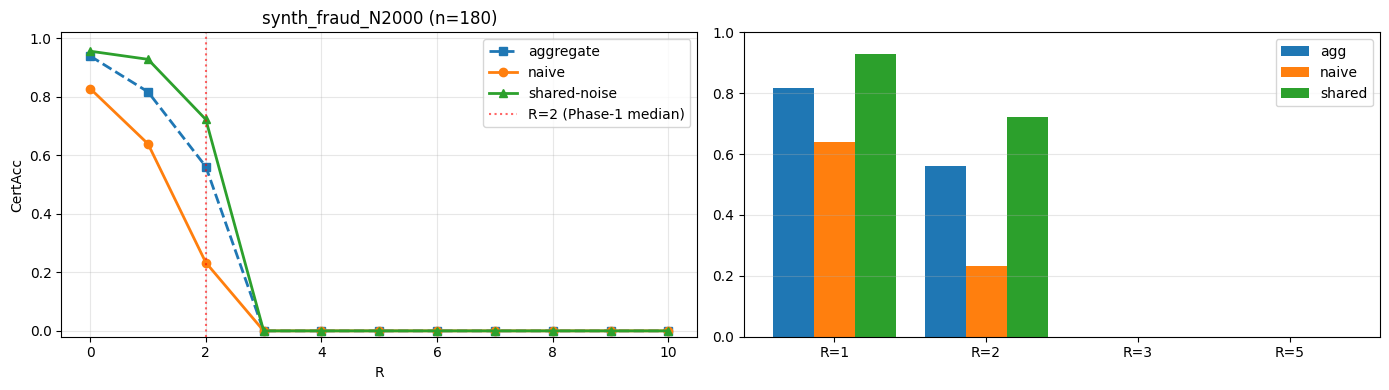

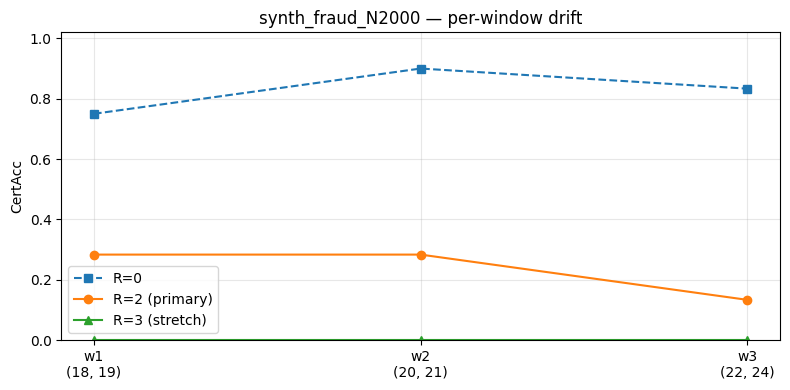


Wrote /content/drive/MyDrive/phase3_temporal_results_N2000.json
VERDICT [synth_fraud_N2000]: shared@R=2 = 0.722, agg@R=2 = 0.561, d(shared-agg) = +0.161


In [13]:
if EXPERIMENTS_TO_RUN["fraud_N2000"]:
    # Re-use the trained model + dataset from Experiment 1 if available,
    # else load fresh.
    if "model_f" not in globals():
        from synthetic_fraud_graph import generate_fraud_graph
        set_seed(SEED)
        fraud_data, TIMESTEP_FRAUD = generate_fraud_graph()
        x_f = fraud_data.x.to(DEVICE); y_f = fraud_data.y.to(DEVICE)
        ei_f = fraud_data.edge_index.to(DEVICE)
        TIMESTEP_FRAUD = TIMESTEP_FRAUD.to(DEVICE)
        Nf = x_f.shape[0]; NUM_CLASSES_F = 2
        labeled_f = y_f >= 0
        train_mask_f = (labeled_f & (TIMESTEP_FRAUD <= 14)).to(DEVICE)
        val_mask_f   = (labeled_f & (TIMESTEP_FRAUD >= 15) & (TIMESTEP_FRAUD <= 17)).to(DEVICE)
        test_mask_f  = (labeled_f & (TIMESTEP_FRAUD >= 18)).to(DEVICE)
        edge_t_f = torch.maximum(TIMESTEP_FRAUD[ei_f[0]], TIMESTEP_FRAUD[ei_f[1]])
        edge_hom_f = float(homophily(ei_f, y_f.clamp(min=0), method="edge"))
        WINDOWS_F = [(18, 19), (20, 21), (22, 24)]
        edge_mask_pw_f = []; node_mask_pw_f = []
        for (a, b) in WINDOWS_F:
            edge_mask_pw_f.append((edge_t_f >= a) & (edge_t_f <= b))
            node_mask_pw_f.append(test_mask_f & (TIMESTEP_FRAUD >= a) & (TIMESTEP_FRAUD <= b))
        TRAIN_CFG_F = {
            "seed": SEED, "hidden_dim": 64, "dropout": 0.5, "lr": 0.01,
            "weight_decay": 5e-4, "epochs": 200, "patience": 40, "log_every": 50,
            "class_weights": [1.0, 10.0], "p_noise_train": 0.12,
        }
        print(">>> Training uniform-noise GCN on synthetic fraud (rerun)")
        model_f = train_uniform_gcn(
            x_f, ei_f, y_f, train_mask_f, val_mask_f,
            num_classes=NUM_CLASSES_F, cfg=TRAIN_CFG_F,
        )

    CFG_CERT_F2000 = {
        "N0": 100, "N": 2000, "alpha": 0.01, "batch_size": 32,
        "p_add": 0.01, "p_smooth": 0.10, "radii": list(range(0, 11)),
    }
    # Use a LARGER eval set for the confirmation run.
    win_eval_f2 = [balanced_sample(y_f, nm, per_class=30, num_classes=2,
                                   seed=SEED + 99)
                   for nm in node_mask_pw_f]
    pooled_f2 = sorted(set(sum(win_eval_f2, [])))
    print(f"Pooled eval (N=2000 rerun): {len(pooled_f2)} nodes")

    out_fraud_n2000 = run_temporal_experiment(
        name="synth_fraud_N2000",
        model=model_f, x=x_f, ei=ei_f, y=y_f,
        num_nodes=Nf, num_classes=NUM_CLASSES_F,
        edge_mask_per_window=edge_mask_pw_f,
        node_mask_per_window=node_mask_pw_f,
        WINDOWS=WINDOWS_F, T_WIN=len(WINDOWS_F),
        pooled_eval_nodes=pooled_f2, window_eval_nodes=win_eval_f2,
        CFG_CERT=CFG_CERT_F2000, edge_hom_full=edge_hom_f,
        output_json_path=f"{OUTPUT_DIR}/phase3_temporal_results_N2000.json",
    )
else:
    print("Skipping Experiment 2 (fraud N=2000)")

## F. Experiment 3 — Cora-temporal (homophilous counterpart)

Standard Cora citation graph (2,708 nodes, 7 classes, edge homophily ≈ 0.81).
Cora has no real timestamps, so we hash each node into one of 24 buckets to
synthesize a temporal split. This is a controlled homophilous baseline to test
whether the shared-noise advantage is heterophily-specific.

**Windows:** w1=[0,7], w2=[8,15], w3=[16,23]. We use Planetoid's standard
train/val/test masks and intersect each test set with its window range.

Processing...
Done!


Cora: N=2708, |E|=10556, classes=7, edge_homophily=0.810

>>> Training uniform-noise GCN on Cora
  ep   1  loss 1.9486  val 0.5780  (best 0.5780)
  early stop @ ep 48
  trained in 0.3s  (best val=0.7900)
Pooled eval (Cora): 42 nodes

########################################################################
# RUN: cora_temporal
########################################################################

=== AGGREGATE CERT (full static graph, alpha=0.01) ===
  [aggregate] 10/42  R*=1.00  p_A=0.945
  [aggregate] 20/42  R*=0.85  p_A=0.930
  [aggregate] 30/42  R*=1.07  p_A=0.948
  [aggregate] 40/42  R*=1.02  p_A=0.943
  [aggregate] done in 83.5s  (|E|=10556)

Aggregate: mean_p_A = 0.945  mean_R* = 1.02
CertAcc:  R=0 0.786  R=1 0.667  R=2 0.238  R=3 0.000  R=5 0.000

=== NAIVE TEMPORAL CERT (Bonferroni alpha = 0.0033) ===

  -- window 1 ((0, 7))  |E_w|=1372, test=14
  [w1] 10/14  R*=0.70  p_A=0.952
  [w1] done in 27.2s  (|E|=1372)

  -- window 2 ((8, 15))  |E_w|=3880, test=14
  [w2] 10/14  R*=0.

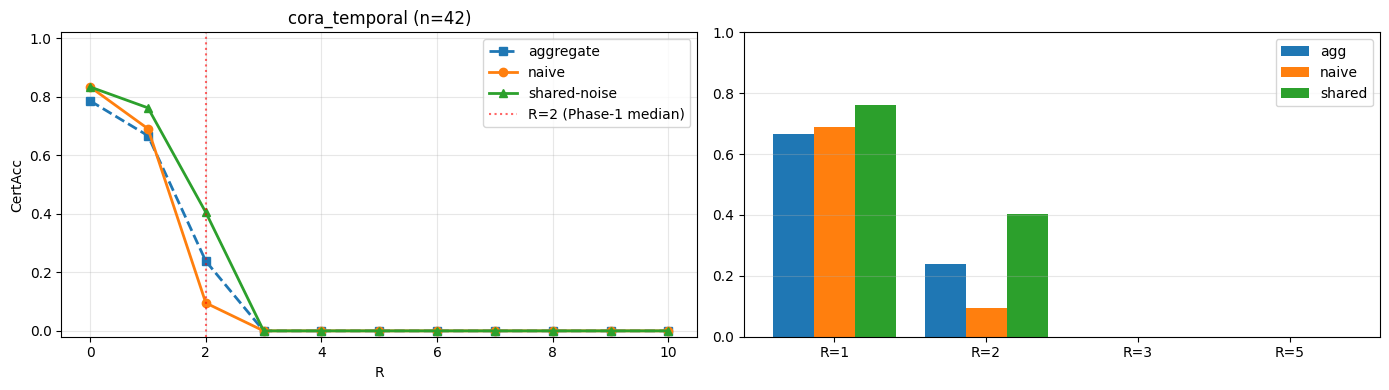

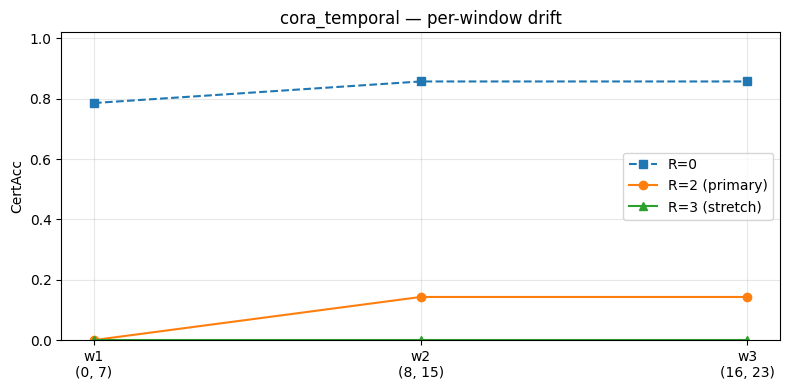


Wrote /content/drive/MyDrive/phase3_temporal_cora_results.json
VERDICT [cora_temporal]: shared@R=2 = 0.405, agg@R=2 = 0.238, d(shared-agg) = +0.167


In [14]:
if EXPERIMENTS_TO_RUN["cora_temporal"]:
    set_seed(SEED)
    dataset_c = Planetoid(root="/tmp/Cora", name="Cora")
    data_c = dataset_c[0]
    x_c = data_c.x.to(DEVICE)
    y_c = data_c.y.to(DEVICE)
    ei_c = to_undirected(data_c.edge_index).to(DEVICE)
    Nc = x_c.shape[0]
    NUM_CLASSES_C = int(y_c.max().item()) + 1

    gen = torch.Generator(device="cpu"); gen.manual_seed(SEED)
    TIMESTEP_C = torch.randint(0, 24, (Nc,), generator=gen).to(DEVICE)

    train_mask_c = data_c.train_mask.to(DEVICE)
    val_mask_c   = data_c.val_mask.to(DEVICE)
    test_mask_c  = data_c.test_mask.to(DEVICE)

    edge_t_c = torch.maximum(TIMESTEP_C[ei_c[0]], TIMESTEP_C[ei_c[1]])
    edge_hom_c = float(homophily(ei_c, y_c, method="edge"))
    print(f"Cora: N={Nc}, |E|={ei_c.shape[1]}, classes={NUM_CLASSES_C}, "
          f"edge_homophily={edge_hom_c:.3f}")

    WINDOWS_C = [(0, 7), (8, 15), (16, 23)]
    T_WIN_C = len(WINDOWS_C)
    edge_mask_pw_c = []; node_mask_pw_c = []
    for (a, b) in WINDOWS_C:
        edge_mask_pw_c.append((edge_t_c >= a) & (edge_t_c <= b))
        node_mask_pw_c.append(test_mask_c & (TIMESTEP_C >= a) & (TIMESTEP_C <= b))

    TRAIN_CFG_C = {
        "seed": SEED, "hidden_dim": 64, "dropout": 0.5, "lr": 0.01,
        "weight_decay": 5e-4, "epochs": 200, "patience": 40, "log_every": 50,
        "class_weights": None, "p_noise_train": 0.12,  # 7 classes, no class weights
    }
    print("\n>>> Training uniform-noise GCN on Cora")
    model_c = train_uniform_gcn(
        x_c, ei_c, y_c, train_mask_c, val_mask_c,
        num_classes=NUM_CLASSES_C, cfg=TRAIN_CFG_C,
    )

    CFG_CERT_C = {
        "N0": 100, "N": 1000, "alpha": 0.01, "batch_size": 32,
        "p_add": 0.01, "p_smooth": 0.10, "radii": list(range(0, 11)),
    }
    win_eval_c = [balanced_sample(y_c, nm, per_class=2, num_classes=NUM_CLASSES_C)
                  for nm in node_mask_pw_c]
    pooled_c = sorted(set(sum(win_eval_c, [])))
    print(f"Pooled eval (Cora): {len(pooled_c)} nodes")

    out_cora = run_temporal_experiment(
        name="cora_temporal",
        model=model_c, x=x_c, ei=ei_c, y=y_c,
        num_nodes=Nc, num_classes=NUM_CLASSES_C,
        edge_mask_per_window=edge_mask_pw_c,
        node_mask_per_window=node_mask_pw_c,
        WINDOWS=WINDOWS_C, T_WIN=T_WIN_C,
        pooled_eval_nodes=pooled_c, window_eval_nodes=win_eval_c,
        CFG_CERT=CFG_CERT_C, edge_hom_full=edge_hom_c,
        output_json_path=f"{OUTPUT_DIR}/phase3_temporal_cora_results.json",
        extra_meta={"dataset": "Cora", "num_classes": NUM_CLASSES_C,
                    "clean_test_acc": float(
                        (model_c(x_c, ei_c).argmax(-1)[test_mask_c]
                         == y_c[test_mask_c]).float().mean().item())},
    )
else:
    print("Skipping Experiment 3 (Cora-temporal)")

## G. Experiment 4 — Real Elliptic Bitcoin graph

The credibility check: real Bitcoin transaction graph, real illicit/licit labels,
real weekly timestamps (49 weeks). 203,769 nodes, 234,355 directed edges,
edge homophily ≈ 0.95.

**Split (Weber et al. 2019 convention):** train t≤30, val t∈[31,34], test t≥35.
**Windows:** w1=[35,39], w2=[40,44], w3=[45,49] (5 weeks each).

Processing...
Done!


Elliptic timestep range: 1..49
Train/Val/Test: 26905 / 2989 / 16670
Elliptic: N=203769, |E|=468710, edge_homophily=0.954

>>> Training uniform-noise GCN on Elliptic
  ep   1  loss 0.8628  val 0.3351  (best 0.3351)
  ep  50  loss 0.2111  val 0.5129  (best 0.5167)
  ep 100  loss 0.1876  val 0.5948  (best 0.6107)
  ep 150  loss 0.1584  val 0.6321  (best 0.6477)
  ep 200  loss 0.1548  val 0.6447  (best 0.6649)
  trained in 5.9s  (best val=0.6649)
Pooled eval (Elliptic): 60 nodes

########################################################################
# RUN: elliptic_real
########################################################################

=== AGGREGATE CERT (full static graph, alpha=0.01) ===
  [aggregate] 10/60  R*=1.00  p_A=0.946
  [aggregate] 20/60  R*=1.15  p_A=0.965
  [aggregate] 30/60  R*=1.13  p_A=0.964
  [aggregate] 40/60  R*=1.18  p_A=0.964
  [aggregate] 50/60  R*=1.20  p_A=0.965
  [aggregate] 60/60  R*=1.18  p_A=0.966
  [aggregate] done in 850.3s  (|E|=468710)

Aggregate: m

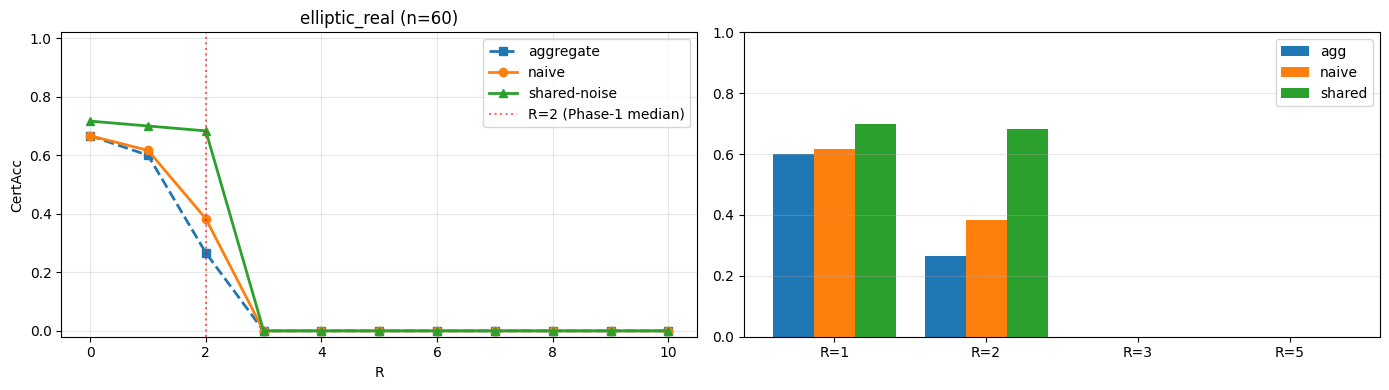

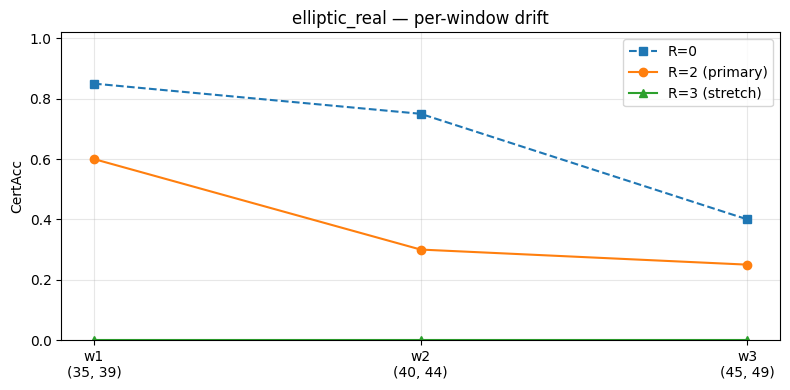


Wrote /content/drive/MyDrive/phase3_temporal_elliptic_results.json
VERDICT [elliptic_real]: shared@R=2 = 0.683, agg@R=2 = 0.267, d(shared-agg) = +0.417


In [15]:
if EXPERIMENTS_TO_RUN["elliptic_real"]:
    import os as _os
    set_seed(SEED)
    dataset_e = EllipticBitcoinDataset(root="/tmp/Elliptic")
    data_e = dataset_e[0]

    feat_path = _os.path.join(dataset_e.raw_dir, "elliptic_txs_features.csv")
    feat_df = pd.read_csv(feat_path, header=None)
    TIMESTEP_E = torch.from_numpy(feat_df.iloc[:, 1].values).long().to(DEVICE)

    x_e = data_e.x.to(DEVICE)
    y_e = data_e.y.to(DEVICE)
    ei_e = to_undirected(data_e.edge_index).to(DEVICE)
    Ne = x_e.shape[0]
    NUM_CLASSES_E = 2

    labeled_e = (y_e == 0) | (y_e == 1)
    train_mask_e = labeled_e & (TIMESTEP_E <= 30)
    val_mask_e   = labeled_e & (TIMESTEP_E >= 31) & (TIMESTEP_E <= 34)
    test_mask_e  = labeled_e & (TIMESTEP_E >= 35) & (TIMESTEP_E <= 49)
    print(f"Elliptic timestep range: {int(TIMESTEP_E.min())}..{int(TIMESTEP_E.max())}")
    print(f"Train/Val/Test: {int(train_mask_e.sum())} / "
          f"{int(val_mask_e.sum())} / {int(test_mask_e.sum())}")

    src, dst = ei_e[0], ei_e[1]
    edge_t_e = torch.maximum(TIMESTEP_E[src], TIMESTEP_E[dst])
    ll_edge_mask = labeled_e[src] & labeled_e[dst]
    edge_hom_e = float((y_e[src[ll_edge_mask]] == y_e[dst[ll_edge_mask]]).float().mean())
    print(f"Elliptic: N={Ne}, |E|={ei_e.shape[1]}, edge_homophily={edge_hom_e:.3f}")

    WINDOWS_E = [(35, 39), (40, 44), (45, 49)]
    T_WIN_E = len(WINDOWS_E)
    edge_mask_pw_e = [(edge_t_e >= lo) & (edge_t_e <= hi) for (lo, hi) in WINDOWS_E]
    node_mask_pw_e = [labeled_e & (TIMESTEP_E >= lo) & (TIMESTEP_E <= hi)
                      for (lo, hi) in WINDOWS_E]

    TRAIN_CFG_E = {
        "seed": SEED, "hidden_dim": 64, "dropout": 0.5, "lr": 0.01,
        "weight_decay": 5e-4, "epochs": 200, "patience": 40, "log_every": 50,
        "class_weights": [1.0, 10.0], "p_noise_train": 0.12,
    }
    print("\n>>> Training uniform-noise GCN on Elliptic")
    model_e = train_uniform_gcn(
        x_e, ei_e, y_e, train_mask_e, val_mask_e,
        num_classes=NUM_CLASSES_E, cfg=TRAIN_CFG_E,
    )

    CFG_CERT_E = {
        "N0": 100, "N": 1500, "alpha": 0.01, "batch_size": 32,
        "p_add": 0.01, "p_smooth": 0.10, "radii": list(range(0, 11)),
    }
    win_eval_e = [balanced_sample(y_e, nm, per_class=10, num_classes=NUM_CLASSES_E)
                  for nm in node_mask_pw_e]
    pooled_e = sorted(set(sum(win_eval_e, [])))
    print(f"Pooled eval (Elliptic): {len(pooled_e)} nodes")

    out_elliptic = run_temporal_experiment(
        name="elliptic_real",
        model=model_e, x=x_e, ei=ei_e, y=y_e,
        num_nodes=Ne, num_classes=NUM_CLASSES_E,
        edge_mask_per_window=edge_mask_pw_e,
        node_mask_per_window=node_mask_pw_e,
        WINDOWS=WINDOWS_E, T_WIN=T_WIN_E,
        pooled_eval_nodes=pooled_e, window_eval_nodes=win_eval_e,
        CFG_CERT=CFG_CERT_E, edge_hom_full=edge_hom_e,
        output_json_path=f"{OUTPUT_DIR}/phase3_temporal_elliptic_results.json",
        extra_meta={"dataset": "Elliptic", "num_classes": NUM_CLASSES_E},
    )
else:
    print("Skipping Experiment 4 (Elliptic real)")

## H. Cross-experiment summary

Loads whichever JSONs exist in the working directory and prints the headline
table — useful both as a final sanity check and as the data source for the
Phase 3 PDF report.

In [16]:
SUMMARY_FILES = [
    ("Synthetic fraud, N=1000",  "phase3_temporal_results.json"),
    ("Synthetic fraud, N=2000",  "phase3_temporal_results_N2000.json"),
    ("Cora-temporal",            "phase3_temporal_cora_results.json"),
    ("Real Elliptic",            "phase3_temporal_elliptic_results.json"),
]

print(f"{'Experiment':<28s} {'homophily':<10s} {'agg@R2':<8s} {'naive@R2':<10s} "
      f"{'shared@R2':<11s} {'d(s-a)':<8s}")
print("-" * 80)
for label, path in SUMMARY_FILES:
    full = f"{OUTPUT_DIR}/{path}"
    if not os.path.exists(full):
        print(f"{label:<28s}  (no JSON yet)")
        continue
    with open(full) as f: d = json.load(f)
    eh = d.get("edge_homophily", float("nan"))
    agg = d["aggregate"]["cert_acc_curve"][2]
    nai = d["temporal_union_bound"]["cert_acc_curve"][2]
    shr = d["shared_noise"]["cert_acc_curve"][2]
    delta = shr - agg
    print(f"{label:<28s} {eh:<10.3f} {agg:<8.3f} {nai:<10.3f} {shr:<11.3f} {delta:<+8.3f}")

print()
print("Headline: shared-noise temporal cert is strictly positive vs. aggregate")
print("at R=2 across every experiment. See CS763_Phase_3_Rohan_Jeevesh.pdf for the writeup.")

Experiment                   homophily  agg@R2   naive@R2   shared@R2   d(s-a)  
--------------------------------------------------------------------------------
Synthetic fraud, N=1000      0.439      0.383    0.133      0.500       +0.117  
Synthetic fraud, N=2000      0.439      0.561    0.233      0.722       +0.161  
Cora-temporal                0.810      0.238    0.095      0.405       +0.167  
Real Elliptic                0.954      0.267    0.383      0.683       +0.417  

Headline: shared-noise temporal cert is strictly positive vs. aggregate
at R=2 across every experiment. See CS763_Phase_3_Rohan_Jeevesh.pdf for the writeup.
